In [1]:
!wget https://www.dropbox.com/scl/fi/qtcrzmsv4jz47cgvr2t0u/train.zip?rlkey=x3sz1h2o797inkqer67q7dg6b&st=gvqo72u9&dl=0

--2026-04-08 08:37:33--  https://www.dropbox.com/scl/fi/qtcrzmsv4jz47cgvr2t0u/train.zip?rlkey=x3sz1h2o797inkqer67q7dg6b
Resolving www.dropbox.com (www.dropbox.com)... 162.125.4.18, 2620:100:601c:18::a27d:612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.4.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc5a7730a6084c1f0a4e95f49133.dl.dropboxusercontent.com/cd/0/inline/C-O8TahNo6k4OMFyC2eFdMET3trFVJkZefzrxQZBGVotFM9e0io_4BdjPvxikB1vg5p0Aj3yQ1ucAS5ULN7UHZRSj3tR2-UcRhEpwStoKUYMjkklOsUHq3JQvmvHy9Oj4tMK-Cj01PqUPLDWEBNJAA1o/file# [following]
--2026-04-08 08:37:35--  https://uc5a7730a6084c1f0a4e95f49133.dl.dropboxusercontent.com/cd/0/inline/C-O8TahNo6k4OMFyC2eFdMET3trFVJkZefzrxQZBGVotFM9e0io_4BdjPvxikB1vg5p0Aj3yQ1ucAS5ULN7UHZRSj3tR2-UcRhEpwStoKUYMjkklOsUHq3JQvmvHy9Oj4tMK-Cj01PqUPLDWEBNJAA1o/file
Resolving uc5a7730a6084c1f0a4e95f49133.dl.dropboxusercontent.com (uc5a7730a6084c1f0a4e95f49133.dl.dropboxusercontent.com)... 162.125.4.15, 2620:100:

In [2]:
!unzip train.zip?rlkey=x3sz1h2o797inkqer67q7dg6b

Archive:  train.zip?rlkey=x3sz1h2o797inkqer67q7dg6b
  inflating: train/Happy/images (34).jpg  
  inflating: train/Happy/images (29).jpg  
  inflating: train/Neutral/images (39).jpg  
  inflating: train/Happy/images (19).jpg  
  inflating: train/Happy/images (22).jpg  
  inflating: train/Happy/images (32).jpg  
  inflating: train/Happy/images (27).jpg  
  inflating: train/Happy/images (33).jpg  
  inflating: train/Happy/images (28).jpg  
  inflating: train/Neutral/images (41).jpg  
  inflating: train/Happy/images (31).jpg  
  inflating: train/Happy/images (14).jpg  
  inflating: train/Happy/images (20).jpg  
  inflating: train/Happy/images (13).jpg  
  inflating: train/Happy/images (16).jpg  
  inflating: train/Neutral/images (42).jpg  
  inflating: train/Happy/images (21).jpg  
  inflating: train/Happy/images (24).jpg  
  inflating: train/Happy/images (35).jpg  
  inflating: train/Happy/images (18).jpg  
  inflating: train/Neutral/images (44).jpg  
  inflating: train/Happy/images (30).

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.applications.mobilenet import MobileNet, preprocess_input
from tensorflow.keras.losses import categorical_crossentropy

In [5]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [6]:
# Working with pre trained model

base_model = MobileNet( input_shape=(224,224,3), include_top= False )

for layer in base_model.layers:
  layer.trainable = False


x = Flatten()(base_model.output)
x = Dense(units=7 , activation='softmax' )(x)

# creating our model.
model = Model(base_model.input, x)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
train_datagen = ImageDataGenerator(
     zoom_range = 0.2,
     shear_range = 0.2,
     horizontal_flip=True,
     rescale = 1./255
)

train_data = train_datagen.flow_from_directory(directory= "/content/train", target_size=(224,224), batch_size=32)


train_data.class_indices

Found 350 images belonging to 7 classes.


{'Angry': 0,
 'Disguist': 1,
 'Fear': 2,
 'Happy': 3,
 'Neutral': 4,
 'Sad': 5,
 'Surprise': 6}

In [ ]:
val_datagen = ImageDataGenerator(rescale = 1./255 )

val_data = val_datagen.flow_from_directory(directory= "/content/train", target_size=(224,224), batch_size=32,)


Found 350 images belonging to 7 classes.


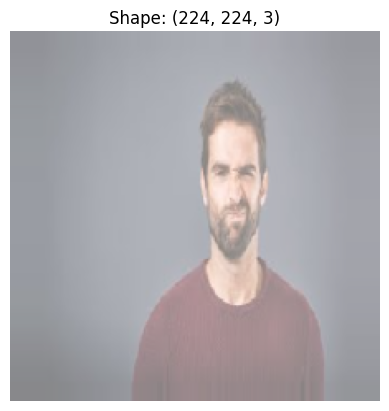

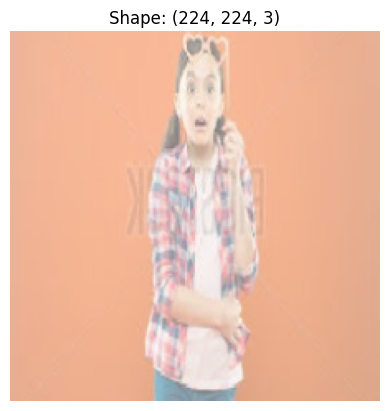

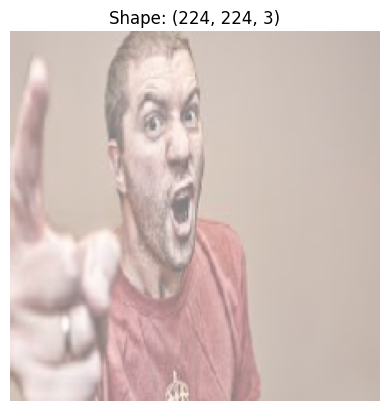

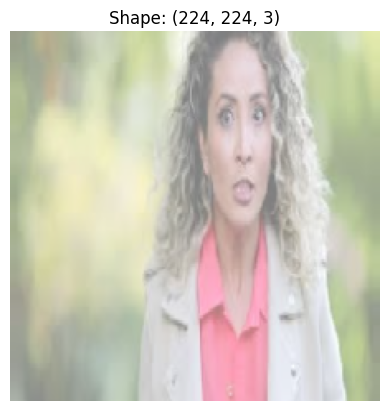

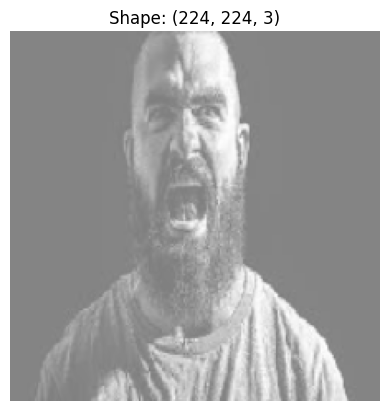

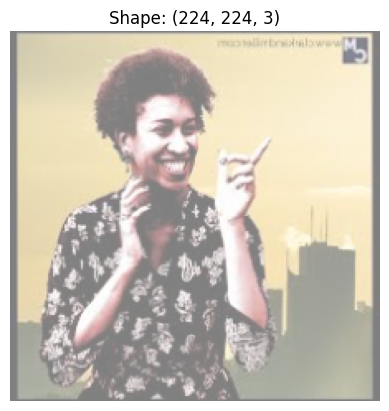

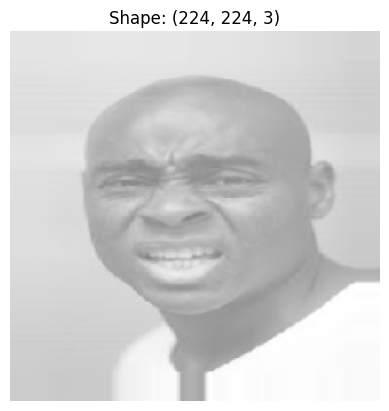

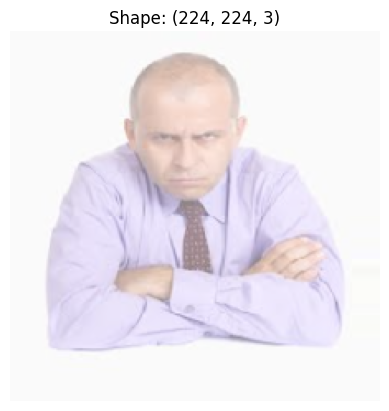

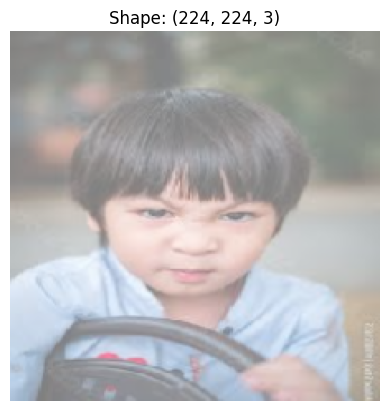

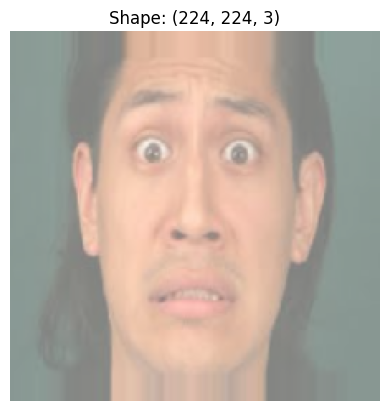

In [ ]:
# Get one batch of images
t_img, label = next(train_data)


def plotImages(img_arr, label):
    count = 0
    for im, l in zip(img_arr, label):

        # If using preprocess_input (MobileNet), convert back for display
        im = (im + 1) / 2   # Rescale from [-1,1] → [0,1]

        plt.imshow(im)
        plt.title(f"Shape: {im.shape}")
        plt.axis('off')   # ✅ FIXED
        plt.show()

        count += 1
        if count == 10:
            break


plotImages(t_img, label)


In [12]:
## having early stopping and model check point

from keras.callbacks import ModelCheckpoint, EarlyStopping

# early stopping
es = EarlyStopping(monitor='val_accuracy', min_delta= 0.01 , patience= 5, verbose= 1, mode='auto')

# model check point
mc = ModelCheckpoint(filepath="best_model.h5", monitor= 'val_accuracy', verbose= 1, save_best_only= True, mode = 'auto')

# puting call back in a list
call_back = [es, mc]

In [16]:
# 1. Compile the model (THIS WAS MISSING ❗)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Train the model
hist = model.fit(
    train_data,
    steps_per_epoch = train_data.samples // train_data.batch_size,
    epochs=30,
    validation_data=val_data,
    validation_steps = val_data.samples // val_data.batch_size,
    callbacks=[es, mc]
)


Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8309 - loss: 1.2813
Epoch 1: val_accuracy did not improve from 0.99687
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.8113 - loss: 1.3511 - val_accuracy: 0.8781 - val_loss: 0.7125
Epoch 2/30
 1/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6875 - loss: 2.1814
Epoch 2: val_accuracy did not improve from 0.99687
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6875 - loss: 2.1814 - val_accuracy: 0.8938 - val_loss: 0.4115
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8731 - loss: 0.7632
Epoch 3: val_accuracy did not improve from 0.99687
10/10 ━━━━━━━━━━━━━━━━━━━━ 66s 4s/step - accuracy: 0.8899 - loss: 0.7323 - val_accuracy: 0.9219 - val_loss: 0.5750
Epoch 4/30
 1/10 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9688 - loss: 0.0399
Epoch 4: val_accuracy did not improve from 0.99687
10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9688 - loss: 0.0399 - val_accuracy: 0.9250 - val_loss: 0.6108
Ep

In [19]:
from tensorflow.keras.models import load_model

model = load_model("/content/best_model.h5")

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
# Loading the best fit model
from keras.models import load_model
model = load_model("/content/best_model.h5")

In [20]:
h =  hist.history
h.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

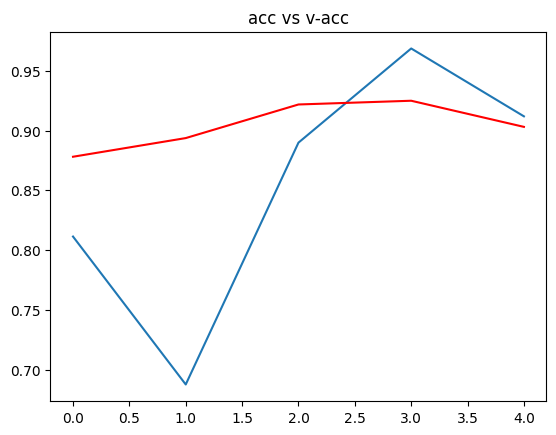

In [21]:
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'] , c = "red")
plt.title("acc vs v-acc")
plt.show()


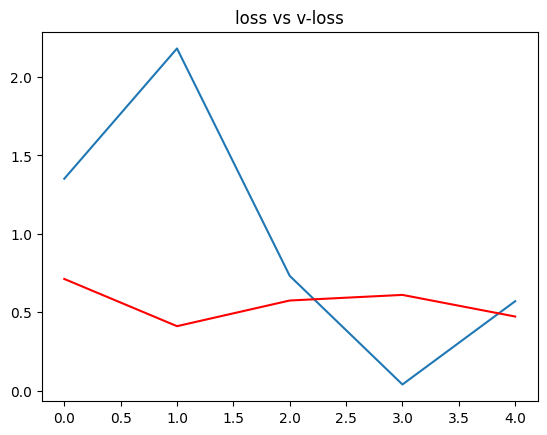

In [22]:
plt.plot(h['loss'])
plt.plot(h['val_loss'] , c = "red")
plt.title("loss vs v-loss")
plt.show()


In [23]:
# just to map o/p values
op = dict(zip( train_data.class_indices.values(), train_data.class_indices.keys()))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 589ms/step
 the image is of Happy


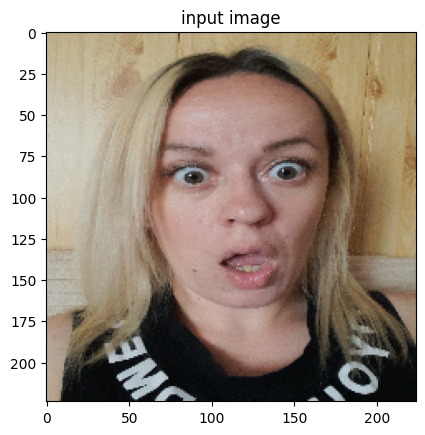

In [24]:
# path for the image to see if it predics correct class

path = "/content/img.jpg"
img = load_img(path, target_size=(224,224) )

i = img_to_array(img)/255
input_arr = np.array([i])
input_arr.shape

pred = np.argmax(model.predict(input_arr))

print(f" the image is of {op[pred]}")

# to display the image
plt.imshow(input_arr[0])
plt.title("input image")
plt.show()